In [1]:
import pandas as pd
import matplotlib.pyplot as plt

box_thickness = 1.0 # Thickness of the plot border box and ticks
data_line_width = 1.5 # Thickness of the plotted data lines 

plt.rcParams.update({
    'font.family': 'sans-serif', 'font.sans-serif': ['Arial'], 'font.weight': 'bold',
    'axes.linewidth': box_thickness, 'axes.labelweight': 'bold', 'axes.titleweight': 'bold',
    'xtick.major.width': box_thickness, 'ytick.major.width': box_thickness, 
    'xtick.direction': 'out', 'ytick.direction': 'out', 'legend.frameon': False,
    'mathtext.default': 'regular'
})

styles = {
    "Pt100": ("Pt100 HClO4", "black", "Pt/C"),
    "Pt66Ru33": ("Pt66Ru33 HClO4", "#994D4D", "Pt$_{66}$Ru$_{33}$/C"),
    "Pt50Ru50": ("Pt50Ru50 HClO4", "red", "Pt$_{50}$Ru$_{50}$/C")
}

data = {mat: pd.read_excel("Summary_current_densities.xlsx", sheet_name=s[0], skiprows=3, usecols=[12, 13], names=['E', 'j']).dropna() for mat, s in styles.items()}
combos = [["Pt100"], ["Pt100", "Pt66Ru33"], ["Pt100", "Pt50Ru50"], ["Pt100", "Pt66Ru33", "Pt50Ru50"]]

for c in combos:
    fig, ax = plt.subplots(figsize=(4.1, 3.8)) 
    
    for mat in c:
        ax.plot(data[mat]['E'], data[mat]['j'], color=styles[mat][1], label=styles[mat][2], lw=data_line_width) 
    
    ax.set(xlim=(0.5, 1.0), xticks=[0.5, 0.6, 0.7, 0.8, 0.9, 1.0], 
           ylim=(0.0, 0.6), yticks=[0.0, 0.2, 0.4, 0.6])
    
    ax.set_xlabel(r'Potential (V$_{RHE}$)', fontsize=14)
    ax.set_ylabel(r'Current Density (mA/cm$^{2}$)', fontsize=14)
    ax.tick_params(labelsize=12)
    
    ax.legend(fontsize=12, loc='upper left', 
              borderaxespad=1.0, 
              handletextpad=0.1)
    
    plt.tight_layout()
    plt.savefig(f"plot_{'_'.join(c)}.png", dpi=300, bbox_inches='tight')
    plt.close() 

In [80]:
import pandas as pd
import numpy as np

def load_summary_data(hclo4_conc_target='0.1'):
    """
    Loads data for a specific HClO4 concentration from the Summary Excel files.
    """
    materials = ['Pt100', 'Pt66Ru33', 'Pt50Ru50']
    
    # Structure: data[material][metric][co_level] = {'x': array, 'y': array}
    data = {m: {'alpha': {}, 'delta_CO': {}, 'delta_H': {}} for m in materials}
    
    # Map for delta_CO ranges to single string representations
    co_range_map = {'0.1-1': '1', '1-10': '10', '10-100': '100'}
    
    # Helper to clean up numbers read as strings from Excel (e.g., '1.0' -> '1')
    def clean_str(val):
        s = str(val).strip()
        if s.endswith('.0'): return s[:-2]
        return s
    
    target_str = clean_str(hclo4_conc_target)
    
    for mat in materials:
        sheet = f"{mat} HClO4"
        
        # 1. Load Transfer Coefficients (alpha)
        df_tc = pd.read_excel("Summary_TCs.xlsx", sheet_name=sheet, header=None)
        for i in range(0, df_tc.shape[1], 2):
            hclo4 = clean_str(df_tc.iloc[1, i])
            co = clean_str(df_tc.iloc[1, i+1])
            if hclo4 == target_str:
                pair = df_tc.iloc[3:, [i, i+1]].apply(pd.to_numeric, errors='coerce').dropna()
                data[mat]['alpha'][co] = {'x': pair.iloc[:, 0].values, 'y': pair.iloc[:, 1].values}
                
        # 2. Load CO Order (delta_CO)
        df_co = pd.read_excel("Summary_CO_order.xlsx", sheet_name=sheet, header=None)
        for i in range(0, df_co.shape[1], 2):
            hclo4 = clean_str(df_co.iloc[1, i])
            co_range = str(df_co.iloc[1, i+1]).strip()
            if hclo4 == target_str and co_range in co_range_map:
                co = co_range_map[co_range]
                pair = df_co.iloc[3:, [i, i+1]].apply(pd.to_numeric, errors='coerce').dropna()
                data[mat]['delta_CO'][co] = {'x': pair.iloc[:, 0].values, 'y': pair.iloc[:, 1].values}
                
        # 3. Load H+ Order (delta_H) - Same across all HClO4 concs
        df_h = pd.read_excel("Summary_pH_order.xlsx", sheet_name=sheet, header=None)
        for i in range(0, df_h.shape[1], 2):
            co = clean_str(df_h.iloc[1, i])
            if co in ['0.1', '1', '10', '100']:
                pair = df_h.iloc[3:, [i, i+1]].apply(pd.to_numeric, errors='coerce').dropna()
                data[mat]['delta_H'][co] = {'x': pair.iloc[:, 0].values, 'y': pair.iloc[:, 1].values}
                
    return data

In [78]:
import pandas as pd
import numpy as np
from scipy.interpolate import interp1d

def load_summary_data(hclo4_conc_target='0.1'):
    """
    Loads raw current densities, resamples onto a 25-point grid (0.5 to 1.0V), 
    and calculates alpha, delta_CO, and delta_H natively.
    """
    materials = ['Pt100', 'Pt66Ru33', 'Pt50Ru50']
    data = {m: {'alpha': {}, 'delta_CO': {}, 'delta_H': {}} for m in materials}
    
    target_C_H = float(hclo4_conc_target)
    C_H_list = [0.1, 0.25, 0.5, 1.0]
    P_CO_list = [0.1, 1.0, 10.0, 100.0]
    
    # Map float P_CO to the string keys expected by the plotting code
    pco_to_str = {0.1: '0.1', 1.0: '1', 10.0: '10', 100.0: '100'}
    
    R, T, F = 8.3145, 298.15, 96485
    slope_f = np.log(10) * R * T / F
    
    # EXACTLY 25 points evenly divided between 0.5V and 1.0V
    E_grid = np.linspace(0.5, 1.0, 25)
    
    for mat in materials:
        sheet = f"{mat} HClO4"
        df = pd.read_excel('Summary_current_densities.xlsx', sheet_name=sheet, header=None)
        raw_data = {}
        
        # 1. Parse raw data into dictionaries
        for i in range(0, df.shape[1], 2):
            c_h_val = pd.to_numeric(df.iloc[1, i], errors='coerce')
            p_co_val = pd.to_numeric(df.iloc[1, i+1], errors='coerce')
            
            if pd.isna(c_h_val) or pd.isna(p_co_val): 
                continue
                
            c_h, p_co = float(c_h_val), float(p_co_val)
            subset = df.iloc[3:, [i, i+1]].apply(pd.to_numeric, errors='coerce').dropna()
            
            E = subset.iloc[:, 0].values
            j = subset.iloc[:, 1].values
            
            if len(E) > 0:
                # Keep strictly positive current densities & sort
                mask = j > 0
                E, j = E[mask], j[mask]
                
                if len(E) > 1:
                    sort_idx = np.argsort(E)
                    E, j = E[sort_idx], j[sort_idx]
                    E, unique_idx = np.unique(E, return_index=True)
                    j = j[unique_idx]
                    raw_data[(c_h, p_co)] = (E, j)
        
        # 2. Calculate Transfer Coefficient (alpha) -> Uses E_RHE
        for p_co in P_CO_list:
            if (target_C_H, p_co) in raw_data:
                E_raw, j_raw = raw_data[(target_C_H, p_co)]
                ln_j_interp = interp1d(E_raw, np.log(j_raw), bounds_error=False, fill_value=np.nan)(E_grid)
                
                alpha = np.full_like(E_grid, np.nan)
                valid = ~np.isnan(ln_j_interp)
                if np.sum(valid) > 1:
                    alpha[valid] = (R * T / F) * np.gradient(ln_j_interp[valid], E_grid[valid])
                
                data[mat]['alpha'][pco_to_str[p_co]] = {'x': E_grid, 'y': alpha}

        # 3. Calculate CO Reaction Order (delta_CO) -> Uses E_RHE
        co_pairs = [(0.1, 1.0, '1'), (1.0, 10.0, '10'), (10.0, 100.0, '100')]
        for p1, p2, label in co_pairs:
            if (target_C_H, p1) in raw_data and (target_C_H, p2) in raw_data:
                E1, j1 = raw_data[(target_C_H, p1)]
                E2, j2 = raw_data[(target_C_H, p2)]
                
                ln_j1 = interp1d(E1, np.log(j1), bounds_error=False, fill_value=np.nan)(E_grid)
                ln_j2 = interp1d(E2, np.log(j2), bounds_error=False, fill_value=np.nan)(E_grid)
                
                delta_co = (ln_j2 - ln_j1) / np.log(p2 / p1)
                data[mat]['delta_CO'][label] = {'x': E_grid, 'y': delta_co}

        # 4. Calculate H+ Reaction Order (delta_H) -> Uses E_SHE
        for p_co in P_CO_list:
            ln_j_matrix = []
            valid_c_h = []
            for c_h in C_H_list:
                if (c_h, p_co) in raw_data:
                    E_raw, j_raw = raw_data[(c_h, p_co)]
                    # Shift RHE to SHE for the common grid
                    E_she = E_raw + slope_f * np.log10(c_h)
                    ln_j = interp1d(E_she, np.log(j_raw), bounds_error=False, fill_value=np.nan)(E_grid)
                    ln_j_matrix.append(ln_j)
                    valid_c_h.append(c_h)
            
            if len(valid_c_h) > 1:
                ln_j_matrix = np.array(ln_j_matrix)
                delta_h = np.full_like(E_grid, np.nan)
                
                for k in range(len(E_grid)):
                    y_vals = ln_j_matrix[:, k]
                    valid_mask = ~np.isnan(y_vals)
                    # Ensure we have at least 2 valid concentrations to compute a slope
                    if np.sum(valid_mask) >= 2:
                        x_vals = np.log(np.array(valid_c_h)[valid_mask])
                        slope, _ = np.polyfit(x_vals, y_vals[valid_mask], 1)
                        delta_h[k] = slope
                        
                data[mat]['delta_H'][pco_to_str[p_co]] = {'x': E_grid, 'y': delta_h}

    return data

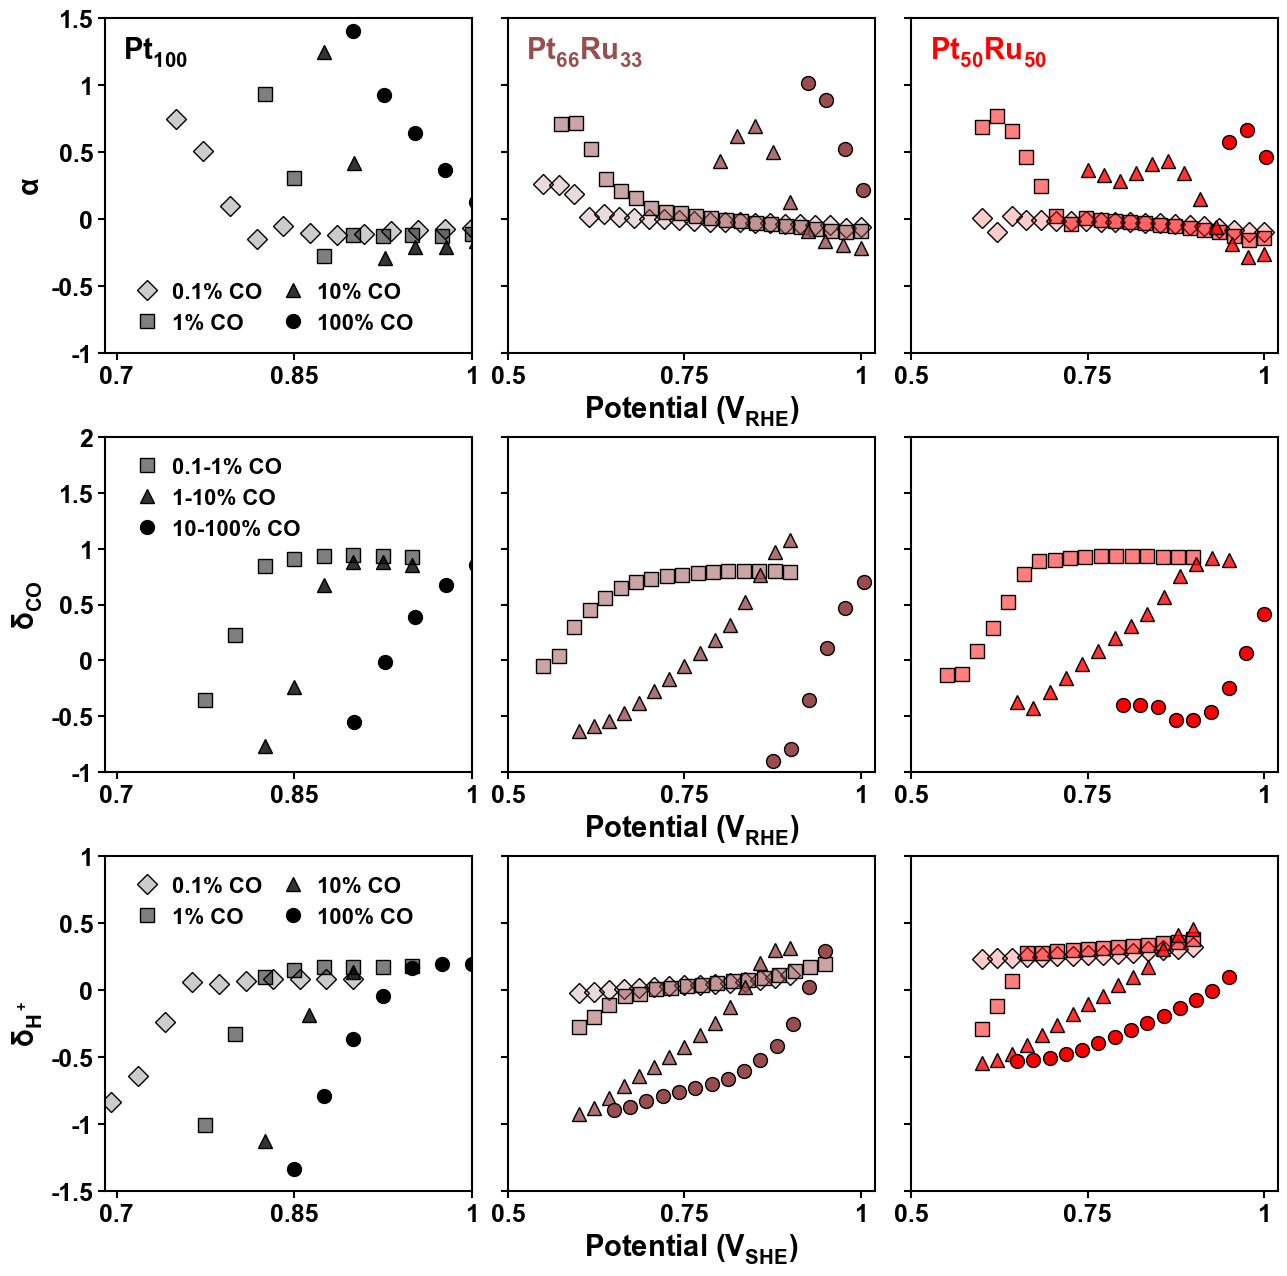

In [84]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
import matplotlib.ticker as ticker
import numpy as np

box_thickness = 1.5       
legend_corner_pad = 0.5   
legend_text_pad = 0.1     
plt.rcParams.update({
    'font.family': 'sans-serif', 'font.sans-serif': ['Arial'], 'font.weight': 'bold',
    'axes.linewidth': box_thickness, 'axes.labelweight': 'bold', 'axes.titleweight': 'bold',
    'xtick.major.width': box_thickness, 'ytick.major.width': box_thickness, 
    'xtick.direction': 'out', 'ytick.direction': 'out', 'legend.frameon': False,
    'mathtext.default': 'regular',
})

def plot_kinetics_grid(data, hclo4_conc='0.1'):
    fig, axes = plt.subplots(3, 3, figsize=(12.75, 12.61))
    materials = ['Pt100', 'Pt66Ru33', 'Pt50Ru50']
    mat_display = {
        'Pt100': 'Pt$_{100}$',
        'Pt66Ru33': 'Pt$_{66}$Ru$_{33}$',
        'Pt50Ru50': 'Pt$_{50}$Ru$_{50}$'
    }
    metrics = ['alpha', 'delta_CO', 'delta_H']
    base_colors = {'Pt100': '#000000', 'Pt66Ru33': '#994D4D', 'Pt50Ru50': '#FF0000'} 
    co_levels = ['0.1', '1', '10', '100']
    markers = {'0.1': 'D', '1': 's', '10': '^', '100': 'o'}
    alphas = {'0.1': 0.2, '1': 0.5, '10': 0.8, '100': 1}
    
    # Cleaned up extra decimals (.0) in limits and ticks
    ylims = {
        'alpha': (-1, 1.5),
        'delta_CO': (-1, 2),
        'delta_H': (-1.5, 1)
    }
    yticks = {
        'alpha': np.arange(-1, 2, 0.5),
        'delta_CO': np.arange(-1, 2.5, 0.5),
        'delta_H': np.arange(-1.5, 1.5, 0.5)
    }
    xlims = {
        'Pt100': (0.69, 1),
        'Pt66Ru33': (0.5, 1.02),
        'Pt50Ru50': (0.5, 1.02)
    }
    xticks = {
        'Pt100': [0.7, 0.85, 1],
        'Pt66Ru33': [0.5, 0.75, 1],
        'Pt50Ru50': [0.5, 0.75, 1]
    }
    ylabels = {'alpha': r'$\alpha$', 'delta_CO': r'$\delta_{CO}$', 'delta_H': r'$\delta_{H^+}$'}

    # Formatter to drop trailing zeros on axis ticks
    min_digit_fmt = ticker.FuncFormatter(lambda x, pos: f"{x:g}")

    for row, metric in enumerate(metrics):
        for col, mat in enumerate(materials):
            ax = axes[row, col]
            mat_data = data[mat][metric]
            base_color = base_colors[mat]
            for co in co_levels:
                if co not in mat_data:
                    continue
                x = mat_data[co]['x']
                y = mat_data[co]['y']
                rgba_color = mcolors.to_rgba(base_color, alpha=alphas[co]) 
                ax.plot(x, y, marker=markers[co], linestyle='', color='none',
                        markerfacecolor=rgba_color, markeredgecolor='k', markersize=10)
            
            ax.set_ylim(ylims[metric])
            ax.set_yticks(yticks[metric])
            ax.set_xlim(xlims[mat])
            ax.set_xticks(xticks[mat])
            ax.tick_params(labelsize=18, length=5)
            ax.xaxis.set_major_formatter(min_digit_fmt)
            ax.yaxis.set_major_formatter(min_digit_fmt)
            
            if col > 0:
                ax.set_yticklabels([])
            if row == 0:
                ax.text(0.05, 0.95, mat_display[mat], transform=ax.transAxes, color=base_color, 
                        fontsize=21, fontweight='bold', verticalalignment='top')  
            if col == 0:
                ax.set_ylabel(ylabels[metric], fontsize=21)  
            if col == 1:
                if metric == 'delta_H':
                    ax.set_xlabel('Potential (V$_{SHE}$)', fontsize=21)
                else:
                    ax.set_xlabel('Potential (V$_{RHE}$)', fontsize=21)

    h_alpha = [Line2D([0], [0], marker=markers[co], linestyle='', markerfacecolor=mcolors.to_rgba('k', alphas[co]), 
                      markeredgecolor='k', markersize=10, label=f"{co}% CO") for co in ['0.1', '1', '10', '100']]
    axes[0, 0].legend(handles=h_alpha, loc='lower left', ncol=2, fontsize=16, 
                      borderaxespad=legend_corner_pad, handletextpad=legend_text_pad, columnspacing=0.4)
    co_ranges = {'1': '0.1-1% CO', '10': '1-10% CO', '100': '10-100% CO'}
    h_co = [Line2D([0], [0], marker=markers[co], linestyle='', markerfacecolor=mcolors.to_rgba('k', alphas[co]), 
                   markeredgecolor='k', markersize=10, label=co_ranges[co]) for co in ['1', '10', '100']]
    axes[1, 0].legend(handles=h_co, loc='upper left', ncol=1, fontsize=16,
                      borderaxespad=legend_corner_pad, handletextpad=legend_text_pad)
    axes[2, 0].legend(handles=h_alpha, loc='upper left', ncol=2, fontsize=16,
                      borderaxespad=legend_corner_pad, handletextpad=legend_text_pad, columnspacing=0.4)

    fig.subplots_adjust(left=0.075, right=0.995, bottom=0.06, top=0.99, hspace=0.25, wspace=0.1)
    plt.savefig(f'kinetics_grid_{hclo4_conc}M.png', dpi=300, transparent=False)
    plt.show()

target_conc = '1'  # Change to '0.25', '0.5', or '1'
data_target = load_summary_data(target_conc)
plot_kinetics_grid(data_target, hclo4_conc=target_conc)